In [2]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score


from pathlib import Path

In [3]:
DATA = Path('..') / 'data'
df = pd.read_csv(DATA / "AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# 1. Inspeccion minima (pre-split)

Solo lo necesario para decidir como splitear: estructura, nulos y la
distribucion de `price` para elegir los bins de estratificacion.
El analisis real va despues del split, sobre el train set.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
df.shape

(48895, 16)

In [6]:
df.isna().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Vemos que hay precios iguales a 0 y tambien vemos en minimum_nights = 1250 lo cual son datos mal tomados directamente. Los puedo eliminar

### Que limpio antes del split y que no

**Antes del split** solo saco las filas con target invalido (`price == 0`):
una fila sin target no sirve ni para entrenar ni para evaluar.

**No** filtro `minimum_nights` aca. Es un outlier en un predictor, no en el
target: si lo saco de todo el dataset tambien lo saco del test, y el test
tiene que reflejar la realidad (en produccion van a llegar filas asi).
Ese tratamiento va dentro del pipeline, ajustado solo con train.

In [8]:
df_clean = df[df['price'] > 0]
df_clean.shape

(48884, 16)

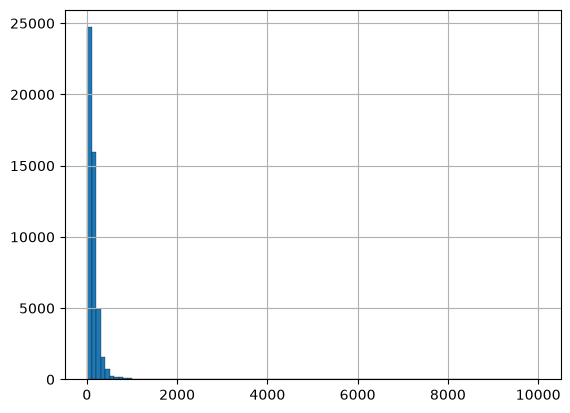

In [9]:
df_clean.price.hist(edgecolor='black', linewidth=0.2, bins=100)

plt.show()

### Estratificacion

Estratifico por `price` binneado, que es el target. Los cortes salen de los
cuantiles del describe (25% = 69, 50% = 106, 75% = 175) y quedan fijos:
no los ajusto mirando resultados.

`price_cat` se usa solo para repartir filas y se descarta enseguida — el
modelo nunca la ve.

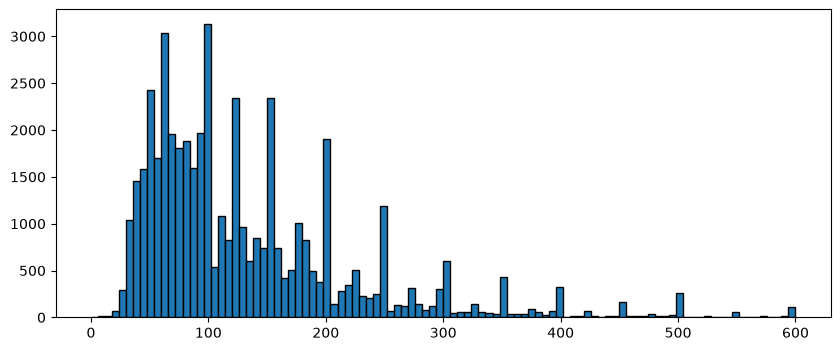

In [10]:
df_clean['price'].hist(bins=100, range=(0, 600), edgecolor='black', grid=False, figsize=(10, 4))
plt.show()

In [11]:
# df['price_cat'] = pd.qcut(df['price'], q=5, labels=[1, 2, 3, 4, 5]) # queda la data perfectamente distribuida. Es menos interpretable igualmente

df_clean['price_cat'] = pd.cut(
    df_clean['price'],
    bins=[0, 60, 100, 150, 250, np.inf],
    labels=[1, 2, 3, 4, 5],
)

df_clean['price_cat'].value_counts().sort_index()

price_cat
1    10052
2    13865
3    10029
4     9730
5     5208
Name: count, dtype: int64

# 2. Train y Test set

In [12]:
train_set, test_set = train_test_split(
    df_clean, test_size=0.2, stratify=df_clean['price_cat'], random_state=42
)

train_set.shape, test_set.shape

((39107, 17), (9777, 17))

Comparo las proporciones para confirmar que el split respeto la distribucion,
y recien despues descarto `price_cat`.

In [13]:
pd.DataFrame({
    'full': df_clean['price_cat'].value_counts(normalize=True),
    'train': train_set['price_cat'].value_counts(normalize=True),
    'test': test_set['price_cat'].value_counts(normalize=True),
}).sort_index()

,full,train,test
price_cat,,,
1,0.205630,0.205641,0.205585
2,0.283631,0.283632,0.283625
3,0.205159,0.205155,0.205175
4,0.199043,0.199044,0.199039
5,0.106538,0.106528,0.106577


In [14]:
for s in (train_set, test_set):
    s.drop(columns='price_cat', inplace=True)

# 3. Explorar y Visualizar la data

De aca en adelante todo se hace sobre `deptos` (copia del train set).
El test set no se vuelve a tocar hasta la evaluacion final.

In [15]:
deptos = train_set.copy()

In [16]:
deptos.shape

(39107, 16)

In [17]:
deptos.isna().sum().sort_values(ascending=False).head(4)

last_review          7974
reviews_per_month    7974
host_name              17
name                   14
dtype: int64

### Distribuciones

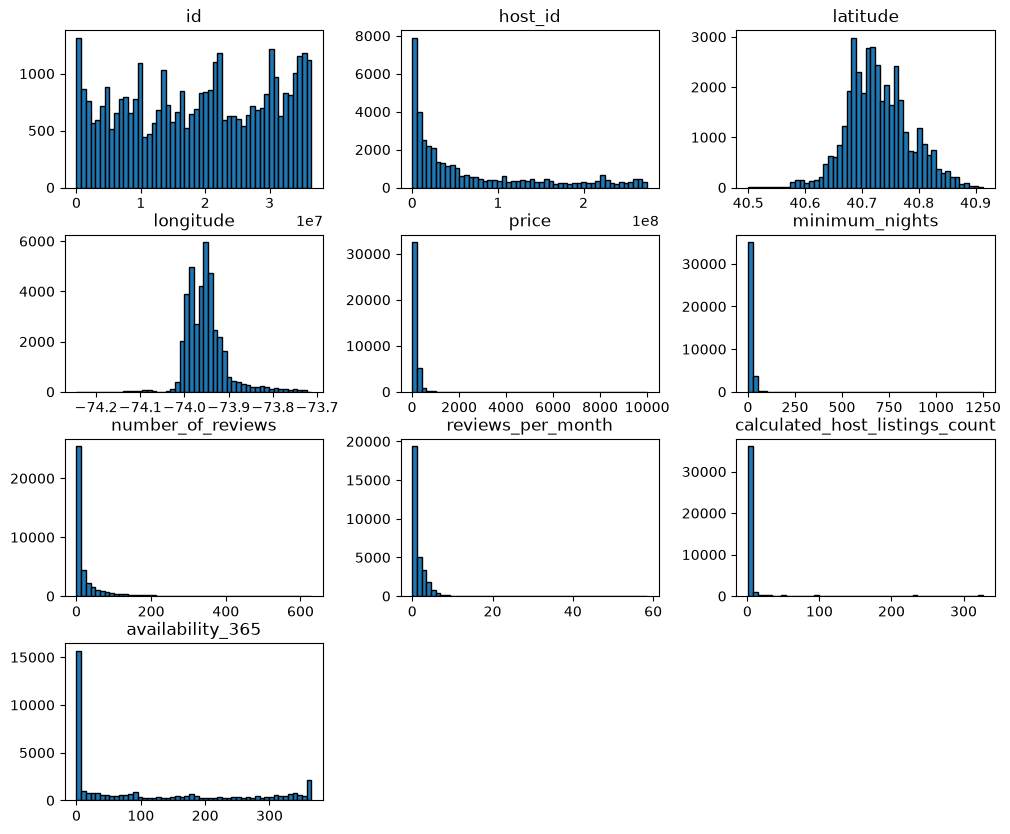

In [18]:
deptos.hist(edgecolor='black', bins=50, grid=False, figsize=(12,10))
plt.show()

En muchas features se pueden ver la presencia de outliers, por eso son tan asimetricas los histogramas y ademas aparece un rango bastante amplio que parece que no tienen valores que caigan en esos rangos

In [19]:
deptos['room_type'].value_counts()

room_type
Entire home/apt    20363
Private room       17835
Shared room          909
Name: count, dtype: int64

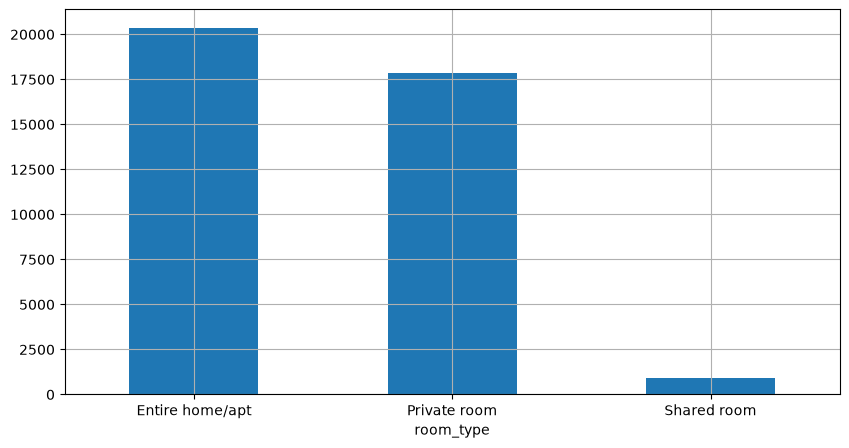

In [20]:
deptos['room_type'].value_counts().sort_index().plot(kind='bar', grid=True, figsize=(10,5), rot=0)
plt.show()

In [21]:
deptos['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        17368
Brooklyn         16015
Queens            4544
Bronx              880
Staten Island      300
Name: count, dtype: int64

In [22]:
deptos.host_id.value_counts()

host_id
219517861    259
107434423    176
30283594      99
137358866     83
12243051      78
            ... 
61303786       1
50045329       1
32715865       1
152177080      1
3130728        1
Name: count, Length: 30877, dtype: int64

In [23]:
deptos.host_name.value_counts()

host_name
Michael         333
David           314
Sonder (NYC)    259
John            235
Alex            233
               ... 
Luz Dary          1
Malu              1
Mymy              1
孙浩                1
James &           1
Name: count, Length: 10007, dtype: int64

### Price por categoria

In [24]:
deptos.groupby(by='neighbourhood_group')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
neighbourhood_group,,,
Manhattan,197.180101,150.0,298.258473
Brooklyn,124.573525,90.0,195.388941
Staten Island,110.983333,75.0,291.450122
Queens,100.081206,75.0,178.458664
Bronx,88.501136,65.0,113.390011


In [25]:
deptos.groupby(by='room_type')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
room_type,,,
Entire home/apt,211.554879,160.0,290.150120
Private room,90.391646,70.0,172.448563
Shared room,72.152915,45.0,111.041385


Pueden presentar tanta varianza debido a que no es lo mismo un departamento/casa entera en Manhattan que en el Bronx

In [26]:
deptos.groupby(['room_type', 'neighbourhood_group'])['price'].agg(['mean', 'median', 'std'])

mean  median         std
room_type       neighbourhood_group                                
Entire home/apt Bronx                130.026316   100.0   98.730152
                Brooklyn             178.457585   145.0  235.897322
                Manhattan            248.725625   190.0  337.316452
                Queens               146.846655   120.0  120.657012
                Staten Island        162.135135   100.0  407.942484
Private room    Bronx                 66.737643    53.0  115.012544
                Brooklyn              76.518523    65.0  133.319067
                Manhattan            118.109565    90.0  202.947389
                Queens                72.302671    59.0  200.721290
                Staten Island         61.506944    51.0   32.834400
Shared room     Bronx                 64.980000    42.5  110.876377
                Brooklyn              51.634069    35.0   58.733402
                Manhattan             89.896000    69.0   97.836119
                Queens                74.320755    38.0  189.108345
                Staten Island         55.250000    30.0   47.718670

In [27]:
pivot = deptos.pivot_table(values='price', index='neighbourhood_group', columns='room_type', aggfunc=['mean', 'median', 'std'])

pivot

mean                                   median  \
room_type           Entire home/apt Private room Shared room Entire home/apt   
neighbourhood_group                                                            
Bronx                    130.026316    66.737643   64.980000           100.0   
Brooklyn                 178.457585    76.518523   51.634069           145.0   
Manhattan                248.725625   118.109565   89.896000           190.0   
Queens                   146.846655    72.302671   74.320755           120.0   
Staten Island            162.135135    61.506944   55.250000           100.0   

                                                         std               \
room_type           Private room Shared room Entire home/apt Private room   
neighbourhood_group                                                         
Bronx                       53.0        42.5       98.730152   115.012544   
Brooklyn                    65.0        35.0      235.897322   133.319067   
Manhattan                   90.0        69.0      337.316452   202.947389   
Queens                      59.0        38.0      120.657012   200.721290   
Staten Island               51.0        30.0      407.942484    32.834400   

                                 
room_type           Shared room  
neighbourhood_group              
Bronx                110.876377  
Brooklyn              58.733402  
Manhattan             97.836119  
Queens               189.108345  
Staten Island         47.718670

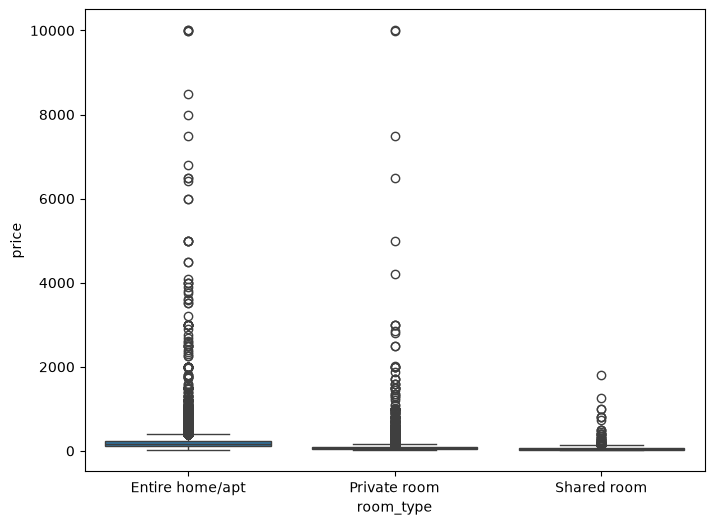

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(data=deptos, x='room_type', y='price')

plt.show()


### Geografia

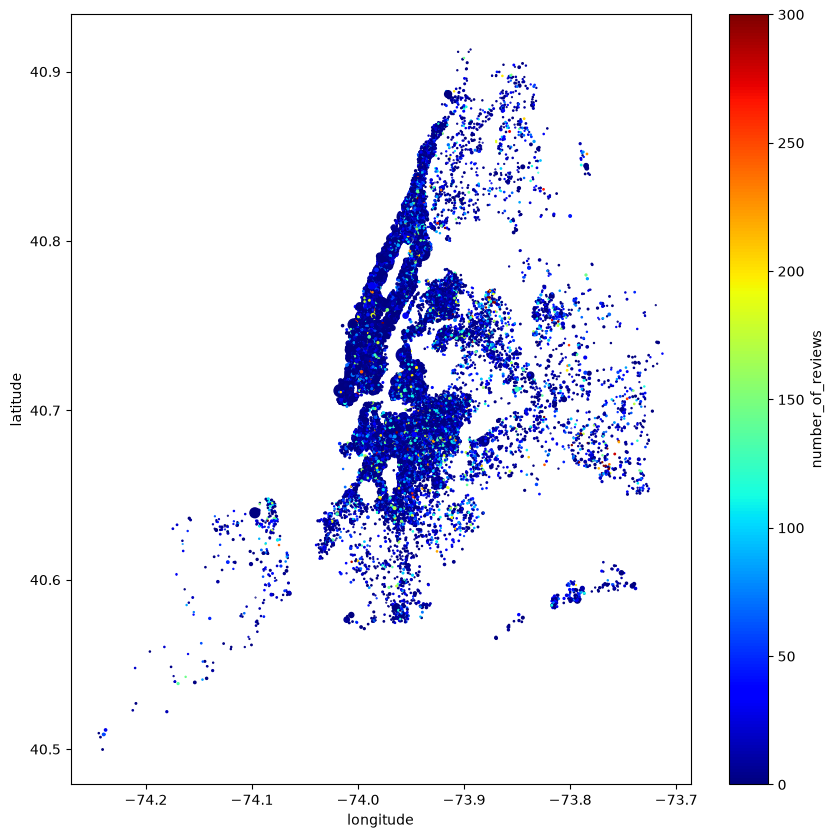

In [29]:
deptos.plot(kind='scatter', x='longitude', y='latitude', c='number_of_reviews', s=deptos['price']/100, cmap='jet', figsize=(10,10), vmax=300)

plt.show()

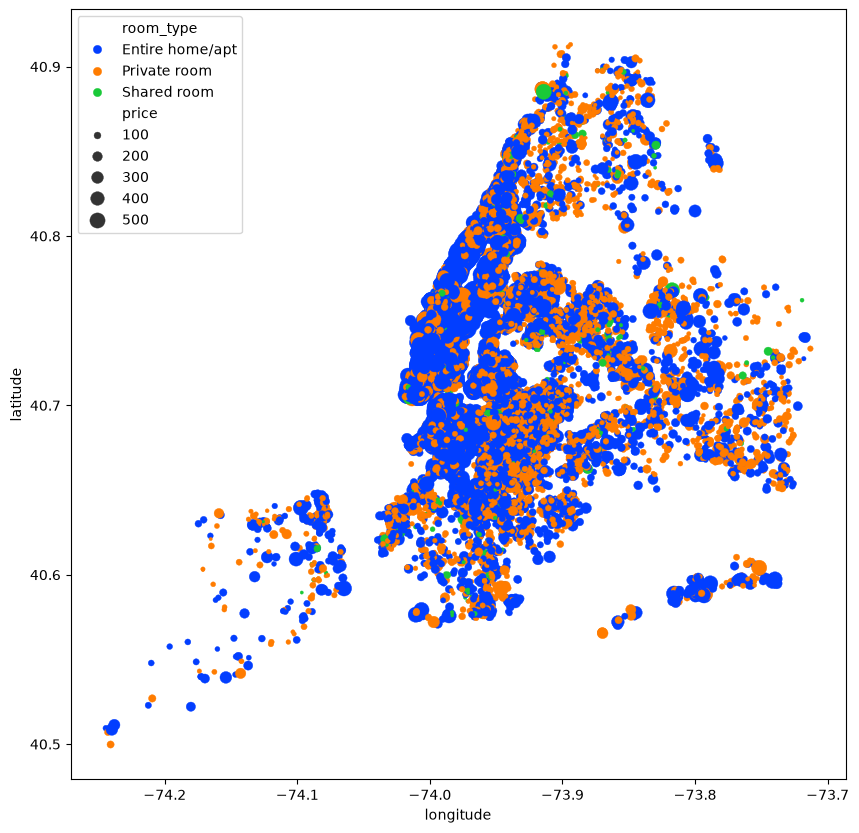

In [30]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=deptos, x='longitude', y='latitude',
                hue='room_type', size=deptos['price'].clip(upper=500),
                sizes=(3, 120), alpha=1, edgecolor=None, palette='bright')
#plt.legend(title='room_type', markerscale=1.5)
plt.show()


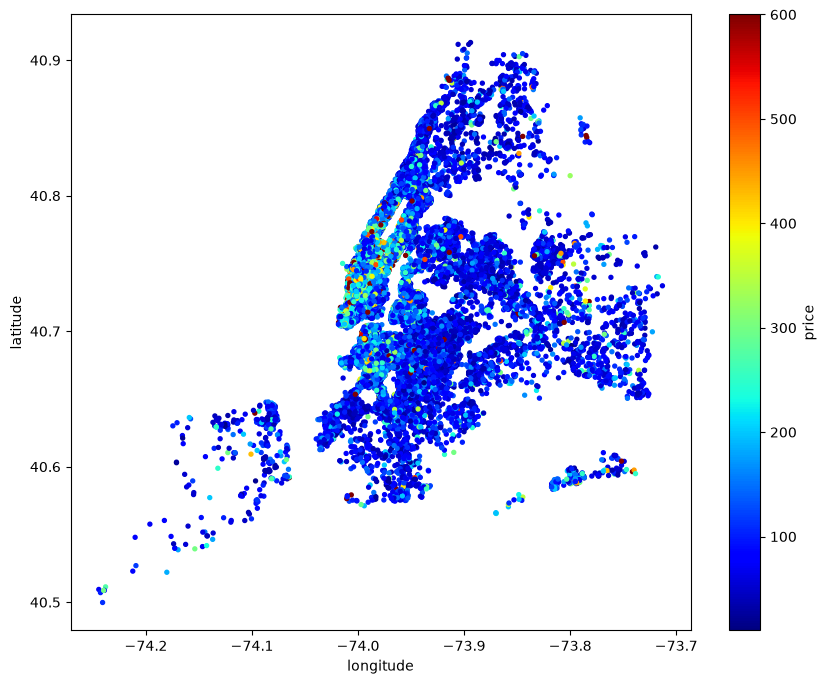

In [31]:
deptos.plot(kind='scatter', x='longitude', y='latitude', c='price', figsize=(10,8), cmap='jet', alpha=1, s=8, vmax=600)

plt.show()

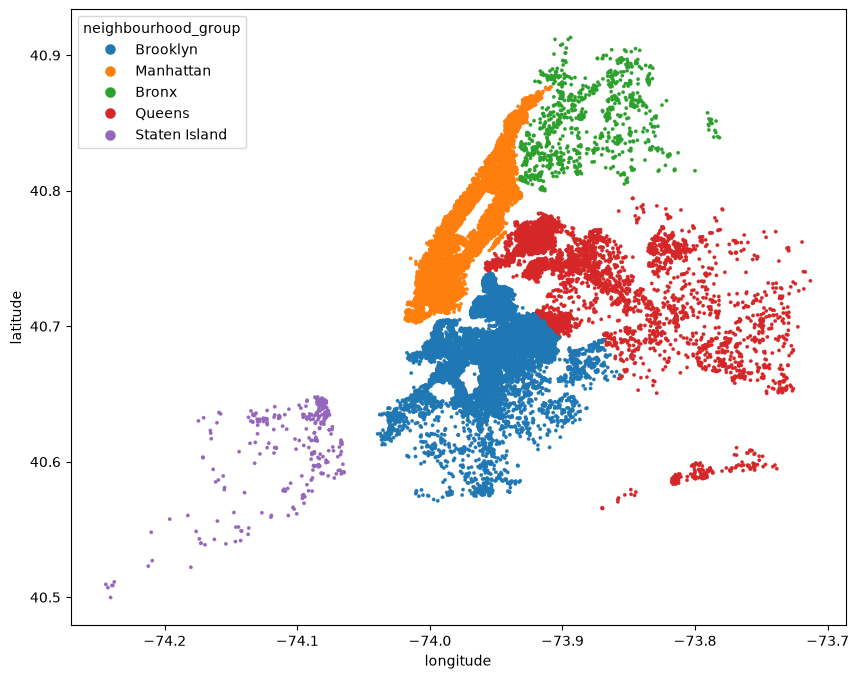

In [32]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=deptos, x='longitude', y='latitude',
                hue='neighbourhood_group', s=6, alpha=1,
                edgecolor=None, palette='tab10')
plt.legend(title='neighbourhood_group', markerscale=3)
plt.show()


* Veo claramente que el numero de reviews no afecta (tanto por lo menos) el precio como pense en primera instancia. Los puntos mas grandes (mayor precio) no tienen tantas reviews (color mas azulados)
* Lo que mas afecta claramente es el barrio donde estan y si el tipo de casa que sea.

### Correlaciones

In [33]:
deptos.info()

<class 'pandas.DataFrame'>
Index: 39107 entries, 26291 to 4199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              39107 non-null  int64  
 1   name                            39093 non-null  str    
 2   host_id                         39107 non-null  int64  
 3   host_name                       39090 non-null  str    
 4   neighbourhood_group             39107 non-null  str    
 5   neighbourhood                   39107 non-null  str    
 6   latitude                        39107 non-null  float64
 7   longitude                       39107 non-null  float64
 8   room_type                       39107 non-null  str    
 9   price                           39107 non-null  int64  
 10  minimum_nights                  39107 non-null  int64  
 11  number_of_reviews               39107 non-null  int64  
 12  last_review                     31133 non-nul

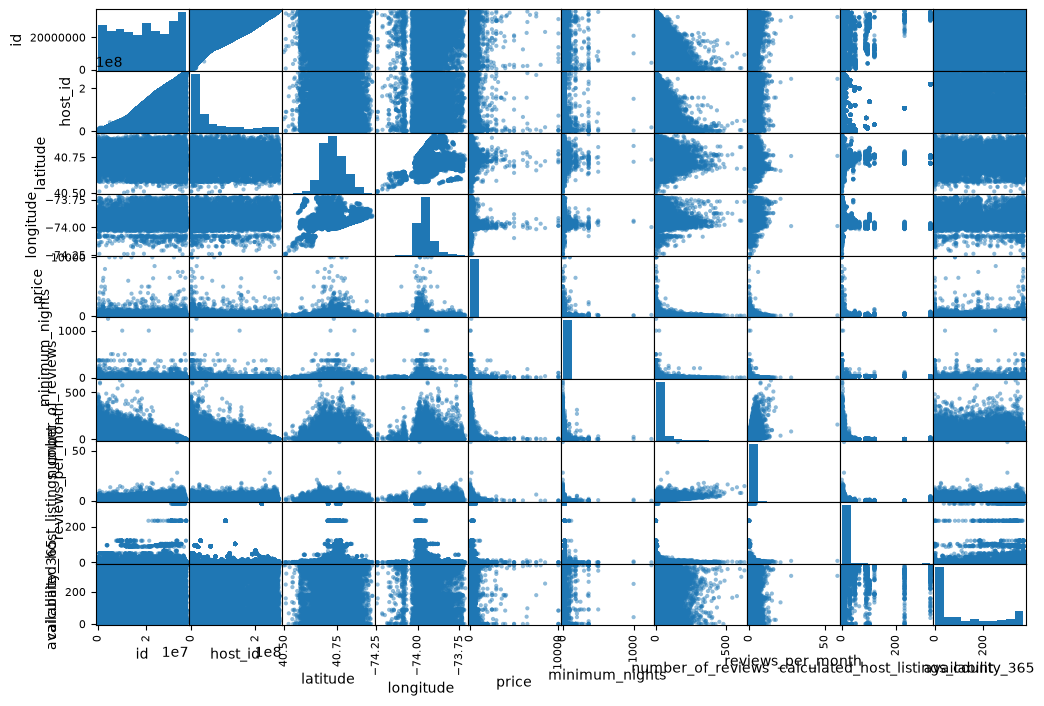

In [34]:
scatter_matrix(deptos.select_dtypes('number'), figsize=(12, 8))
  
plt.show()

In [35]:
corr_matrix = deptos.select_dtypes('number').corr()
corr_matrix['price'].sort_values(ascending=False)

price                             1.000000
availability_365                  0.078338
calculated_host_listings_count    0.054431
minimum_nights                    0.046618
latitude                          0.033156
host_id                           0.013512
id                                0.007524
reviews_per_month                -0.032547
number_of_reviews                -0.047771
longitude                        -0.145718
Name: price, dtype: float64

* Vemos que las correlaciones con las features numericas son bajas, y como ya vimos anteriormente, hay mucho mas correlacion con el room_type y neighbourdhood_group.

# Preparar la data para ML

* Tengo que limpiar la data primero

# 4. Preparar la data para ML

Todo lo que sigue hasta el pipeline es **exploracion**: miro como quedarian
los datos despues de cada transformacion para decidir que hacer, pero trabajo
sobre una copia (`explor`) y no piso nada. El pipeline de la seccion 5 es la
unica version que cuenta.

In [36]:
explor = train_set.drop(columns='price').copy()
explor_labels = train_set['price'].copy()

explor.shape

(39107, 15)

### Nulos

In [37]:
explor.isna().sum().sort_values(ascending=False).head(4)

reviews_per_month    7974
last_review          7974
host_name              17
name                   14
dtype: int64

In [38]:
# Los NaN de reviews_per_month y last_review coinciden con number_of_reviews == 0
explor[explor['number_of_reviews'] == 0].shape

(7974, 15)

Los NaN en `reviews_per_month` y `last_review` vienen de los airbnb que
no tienen reviews (`number_of_reviews == 0`). No son datos faltantes: son
ceros reales. Por eso imputo con **0** y no con la mediana.

De `last_review` no me sirve la fecha en si, pero si la informacion de que
esta vacia -> la convierto en el flag `never_reviewed`.

In [39]:
# Cuantas filas tendrian never_reviewed = 1
explor['last_review'].isna().sum()

np.int64(7974)

### Columnas que descarto

`id`, `name`, `host_id`, `host_name`: identificadores o texto libre, aportan
poco a un modelo tabular.

In [40]:
explor.host_name.nunique(), explor['name'].nunique()

(10007, 38447)

### neighbourhood

Son demasiadas categorias para one-hot. Una alternativa es agrupar las poco
frecuentes en `'Other'`, pero aun asi quedan muchas. Me quedo con
`neighbourhood_group` (5 categorias) y descarto `neighbourhood`; la senal
geografica fina la captura el `ClusterSimilarity` sobre lat/long.

In [41]:
frecuencia_barrios = explor['neighbourhood'].value_counts()
frecuentes = frecuencia_barrios[frecuencia_barrios >= 50].index
print(f'Barrios que quedan: {len(frecuentes)} de {len(frecuencia_barrios)}')

Barrios que quedan: 89 de 217


### minimum_nights

Hay una fila con `minimum_nights = 1250`, imposible. Filtro `<= 365`.
Esto es un borrado de **filas**, asi que no puede ir dentro del pipeline
(ver nota en la seccion 5).

In [42]:
(explor['minimum_nights'] > 365).sum()

np.int64(10)

### availability_365

In [43]:
explor.availability_365.value_counts().head()

availability_365
0      14047
365     1023
364      396
1        311
89       288
Name: count, dtype: int64

Muchos con 0 dias disponibles y otros con 364/365. Por ahora no hago nada,
pero se podria agregar un flag.

### Transformaciones numericas

Las features numericas son muy asimetricas. Comparo `log` contra la escala
original para confirmar que `log1p` las normaliza.

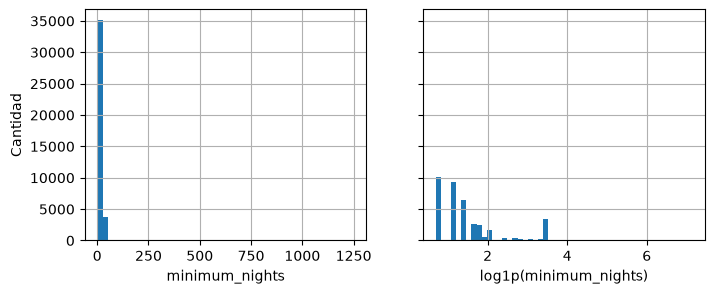

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
explor["minimum_nights"].hist(ax=axs[0], bins=50)
np.log1p(explor["minimum_nights"]).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("minimum_nights")
axs[1].set_xlabel("log1p(minimum_nights)")
axs[0].set_ylabel("Cantidad")

plt.show()

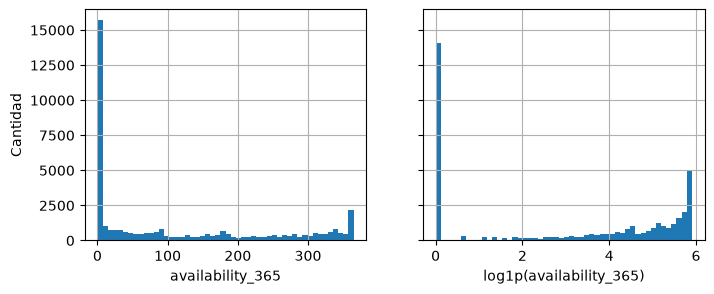

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
explor["availability_365"].hist(ax=axs[0], bins=50)
np.log1p(explor["availability_365"]).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("availability_365")
axs[1].set_xlabel("log1p(availability_365)")
axs[0].set_ylabel("Cantidad")

plt.show()

### Custom Transformer: ClusterSimilarity

Esta clase si forma parte del pipeline. Agrupa lat/long en `n_clusters`
centros y devuelve la similitud RBF de cada punto a cada centro.

In [46]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

Lo pruebo suelto para ver que los clusters caigan sobre las zonas densas
de la ciudad.

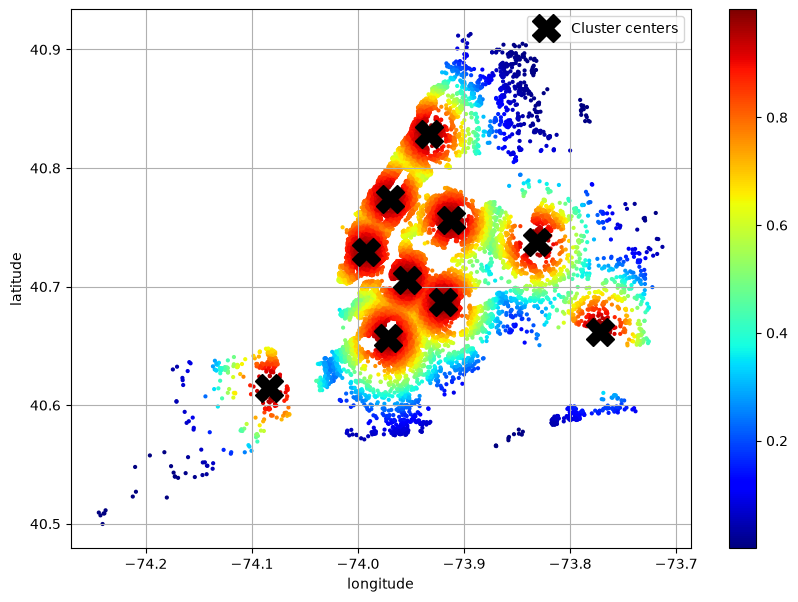

In [47]:
cluster_simil_test = ClusterSimilarity(n_clusters=10, gamma=400., random_state=42)
similarities = cluster_simil_test.fit_transform(explor[["latitude", "longitude"]])

explor.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=4, c=similarities.max(axis=1),
            cmap="jet", colorbar=True,
            legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil_test.kmeans_.cluster_centers_[:, 1],
         cluster_simil_test.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")

plt.show()

### Resumen de transformaciones

**Categoricas**
* `reviews_per_month`: NaN -> 0 (no hay reviews, no es dato faltante)
* `last_review` -> `never_reviewed` (1 si NaN, 0 si no)
* one-hot en `neighbourhood_group` y `room_type`
* descarto `id`, `name`, `host_id`, `host_name`, `neighbourhood`

**Numericas**
* `log1p` + estandarizar
* `latitude`/`longitude` -> `ClusterSimilarity`

**Fuera del pipeline** (borra filas): filtro `minimum_nights <= 365`

# 5. Pipeline

### Que va dentro del pipeline y que no

El pipeline solo puede transformar columnas, **no puede borrar filas**
(`transform` tiene que devolver la misma cantidad de filas que recibe).
Asi que el filtro de `minimum_nights <= 365` queda afuera, como paso previo
aplicado solo al train.

Tambien ojo con el `ColumnTransformer`: cada transformer recibe las columnas
**originales** en paralelo, no la salida del anterior. Por eso imputar
`reviews_per_month` en un transformer y aplicarle `log1p` en otro no funciona:
el segundo seguiria viendo los NaN. Hay que encadenarlos en un `Pipeline`.

In [48]:
# Paso previo (fuera del pipeline): saco la fila con minimum_nights absurdo.
# Solo sobre train -- el test set queda intacto.
deptos = train_set.drop(columns='price')
deptos_labels = train_set['price'].copy()

mask = deptos['minimum_nights'] <= 365
deptos = deptos[mask]
deptos_labels = deptos_labels[mask]

deptos.shape, deptos_labels.shape

((39097, 15), (39097,))

In [49]:
deptos.isna().sum().sort_values(ascending=False).head(4)

reviews_per_month    7969
last_review          7969
host_name              17
name                   14
dtype: int64

### Definicion de columnas

`reviews_per_month` va aparte porque necesita imputacion con 0 (no con la
mediana): los NaN significan "no tiene reviews", no "dato faltante".

In [50]:
num_attribs = ['minimum_nights', 'number_of_reviews',
               'calculated_host_listings_count', 'availability_365']

reviews_attrib = ['reviews_per_month']   # imputa 0, despues log1p

geo_attribs = ['latitude', 'longitude']  # van al ClusterSimilarity

cat_attribs = ['neighbourhood_group', 'room_type']

drop_attribs = ['id', 'name', 'host_id', 'host_name', 'neighbourhood']

### Sub-pipelines

* `log1p_pipeline`: imputa mediana -> log1p -> estandariza.
* `reviews_pipeline`: imputa 0 -> log1p -> estandariza.
* `never_reviewed_pipeline`: convierte `last_review` en el flag binario
  (1 si es NaN, 0 si no).
* `cat_pipeline`: one-hot con `handle_unknown='ignore'`.

In [51]:
log1p_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

log1p_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    log1p_transformer,
    StandardScaler(),
)

reviews_pipeline = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0),
    log1p_transformer,
    StandardScaler(),
)

def to_never_reviewed(X):
    # X llega como DataFrame/array con la columna last_review
    return pd.DataFrame(X).isna().astype(int).to_numpy()

def never_reviewed_name(function_transformer, feature_names_in):
    return ['never_reviewed']

never_reviewed_transformer = FunctionTransformer(
    to_never_reviewed,
    feature_names_out=never_reviewed_name,
    #feature_names_out=lambda self, names: ['never_reviewed'],
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=400., random_state=42)

### ColumnTransformer

`remainder='drop'` se encarga solo de tirar `id`, `name`, `host_id`,
`host_name` y `neighbourhood`: cualquier columna que no nombre explicitamente
queda afuera.

In [52]:
preprocessing = ColumnTransformer([
    ('log1p',          log1p_pipeline,              num_attribs),
    ('reviews',        reviews_pipeline,            reviews_attrib),
    ('never_reviewed', never_reviewed_transformer,  ['last_review']),
    ('geo',            cluster_simil,               geo_attribs),
    ('cat',            cat_pipeline,                cat_attribs),
], remainder='drop')

preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log1p', ...), ('reviews', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [53]:
deptos_prepared = preprocessing.fit_transform(deptos)
deptos_prepared.shape

(39097, 24)

In [54]:
feature_names = preprocessing.get_feature_names_out()
feature_names

array(['log1p__minimum_nights', 'log1p__number_of_reviews',
       'log1p__calculated_host_listings_count', 'log1p__availability_365',
       'reviews__reviews_per_month', 'never_reviewed__never_reviewed',
       'geo__Cluster 0 similarity', 'geo__Cluster 1 similarity',
       'geo__Cluster 2 similarity', 'geo__Cluster 3 similarity',
       'geo__Cluster 4 similarity', 'geo__Cluster 5 similarity',
       'geo__Cluster 6 similarity', 'geo__Cluster 7 similarity',
       'geo__Cluster 8 similarity', 'geo__Cluster 9 similarity',
       'cat__neighbourhood_group_Bronx',
       'cat__neighbourhood_group_Brooklyn',
       'cat__neighbourhood_group_Manhattan',
       'cat__neighbourhood_group_Queens',
       'cat__neighbourhood_group_Staten Island',
       'cat__room_type_Entire home/apt', 'cat__room_type_Private room',
       'cat__room_type_Shared room'], dtype=object)

In [55]:
deptos_prepared_df = pd.DataFrame(
    deptos_prepared, columns=feature_names, index=deptos.index
)
deptos_prepared_df.head()

,log1p__minimum_nights,log1p__number_of_reviews,log1p__calculated_host_listings_count,log1p__availability_365,reviews__reviews_per_month,never_reviewed__never_reviewed,geo__Cluster 0 similarity,geo__Cluster 1 similarity,geo__Cluster 2 similarity,geo__Cluster 3 similarity,...,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__neighbourhood_group_Bronx,cat__neighbourhood_group_Brooklyn,cat__neighbourhood_group_Manhattan,cat__neighbourhood_group_Queens,cat__neighbourhood_group_Staten Island,cat__room_type_Entire home/apt,cat__room_type_Private room,cat__room_type_Shared room
26291,-0.127470,1.273672,-0.458494,0.544922,1.225462,0.0,0.640982,0.602321,3.586530e-06,0.000473,...,0.170049,0.058720,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
24741,-0.127470,-0.832238,-0.458494,0.499750,-0.872375,0.0,0.454534,0.796144,1.659952e-04,0.008031,...,0.303627,0.350684,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
20415,-0.127470,0.728326,0.016717,-1.213941,-0.002665,0.0,0.476157,0.440684,3.463212e-07,0.000135,...,0.076058,0.019094,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
42191,2.166644,-1.275131,0.016717,1.052184,-0.940175,1.0,0.355568,0.921030,7.006371e-06,0.003701,...,0.106016,0.114275,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
18753,0.130943,1.680044,-0.458494,0.374869,1.430170,0.0,0.282405,0.109392,1.090264e-02,0.001906,...,0.812671,0.457517,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Chequeos

Sin NaN, y el test set pasa por el mismo `preprocessing` ya ajustado
(`transform`, nunca `fit_transform`).

In [56]:
deptos_prepared_df.isna().sum().max()

np.int64(0)

In [57]:
# El test set NO se filtra ni se toca: solo se transforma con lo aprendido en train.
X_test = test_set.drop(columns='price')
y_test = test_set['price'].copy()

X_test_prepared = preprocessing.transform(X_test)
X_test_prepared.shape

(9777, 24)

# Elegir y entrenar el Modelo


### Linear regressor

* Uso el target sin transformar con log

In [152]:
lin_reg = make_pipeline(preprocessing, LinearRegression())

In [153]:
lin_rmses = -cross_val_score(lin_reg, deptos, deptos_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count     10.000000
mean     228.760572
std       53.974668
min      155.054249
25%      198.332787
50%      225.157365
75%      257.702271
max      324.505479
dtype: float64

In [156]:
lin_rmses = -cross_val_score(lin_reg, deptos, deptos_labels,
                              scoring="neg_mean_absolute_error", cv=10)
pd.Series(lin_rmses).describe()

count    10.000000
mean     72.258167
std       3.587176
min      66.709512
25%      71.093669
50%      71.285429
75%      73.380776
max      79.550570
dtype: float64

* Pruebo con el target mejorado a ver si mejora

In [159]:
lin_reg_log = TransformedTargetRegressor(
    regressor=lin_reg,
    func=np.log1p,
    inverse_func=np.expm1,
)

lin_maes_log = -cross_val_score(lin_reg_log, deptos, deptos_labels,
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_maes_log).describe()


count     10.000000
mean     229.988474
std       54.156173
min      156.365267
25%      199.734220
50%      226.626280
75%      258.649164
max      325.228679
dtype: float64

In [ ]:
lin_reg_log = TransformedTargetRegressor(
    regressor=lin_reg,
    func=np.log1p,
    inverse_func=np.expm1,
)

lin_maes_log = -cross_val_score(lin_reg_log, deptos, deptos_labels,
                                scoring="neg_mean_absolute_error", cv=10)
pd.Series(lin_maes_log).describe()


count    10.000000
mean     60.946641
std       4.011768
min      54.798108
25%      59.535595
50%      59.906755
75%      62.099959
max      68.917280
dtype: float64

* Vemos que el promedio del error es muchisimo mayor si consideramos el error cuadratico medio, esto es debido a la cantidad de outliers que hay.
* Si consideramos el error absoluto medio baja mucho (mas robusto), pero igual no se si es bajo, habria que probar el modelo entrenado y ver en que estratos de precios le esta errando mas. Quizas se infla a 60 el error promedio debido a unicamente el error que tiene el modelo en predecir los outliers pero para el resto quizas funciona bien.

### Voy a probar un Random Forest

In [ ]:
deptos.head()

In [ ]:
forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, deptos, deptos_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [161]:
pd.Series(forest_rmses).describe()

count     10.000000
mean     230.277539
std       52.570989
min      161.538684
25%      200.172517
50%      222.527213
75%      268.087430
max      325.209529
dtype: float64

* Veo si le aplico un log al target a ver si mejora en algo

In [ ]:
forest_reg_log = TransformedTargetRegressor(
    regressor=forest_reg,
    func=np.log1p,
    inverse_func=np.expm1,
)

forest_rmses_log = -cross_val_score(forest_reg_log, deptos, deptos_labels,
                                scoring="neg_root_mean_squared_error", cv=5)

In [163]:
pd.Series(forest_rmses_log).describe()

count      5.000000
mean     226.437310
std       45.340003
min      153.256967
25%      215.129505
50%      246.791775
75%      246.911793
max      270.096508
dtype: float64

In [164]:
forest_rmses_log = -cross_val_score(forest_reg_log, deptos, deptos_labels,
                                scoring="neg_mean_absolute_error", cv=5)

In [165]:
pd.Series(forest_rmses_log).describe()

count     5.000000
mean     57.435200
std       3.039834
min      52.811391
25%      56.805138
50%      57.326118
75%      59.486909
max      60.746447
dtype: float64

* REALMENTE PARA SABER SI ESTA FUNCIONANDO BIEN O MAL TENDRIA QUE VER LOS ERRORES QUE COMETE EN CADA ESTRATO. CREO QUE EL PROBLEMA ESTA SIENDO NO PREDECIR CORRECTAMENTE LOS OUTLIERS.
* Usando un RandomForest (sin tunear) hay una pequeña mejoria en el error medio absoluto.

# 6. Diagnostico: en que estrato se equivoca el modelo

El MAE global (~60) no dice nada util: es un promedio entre un modelo que en el
grueso de los datos erra 20-40 dolares y una cola larga donde erra cientos.
Un error de 60 en un airbnb de 50 es inaceptable; en uno de 500 es tolerable.

Para ver donde falla uso `cross_val_predict`: me da una prediccion out-of-fold
para **cada** fila del train (cada fila predicha por un modelo que no la vio),
asi puedo agrupar los errores sin tocar el test set.


In [61]:
from sklearn.model_selection import cross_val_predict

# Prediccion out-of-fold para cada fila del train
y_pred = cross_val_predict(forest_reg_log, deptos, deptos_labels, cv=5)

e = pd.DataFrame({'y': deptos_labels.values, 'y_pred': y_pred})
e['residuo'] = e['y_pred'] - e['y']       # >0 sobreestima, <0 subestima
e['ae']      = e['residuo'].abs()
e['rel']     = e['ae'] / e['y']         # error relativo

bins = [0, 60, 100, 150, 250, np.inf]
e['bin']      = pd.cut(e['y'],    bins=bins)   # estrato del precio REAL
e['bin_pred'] = pd.cut(e['y_pred'], bins=bins)   # estrato del precio PREDICHO

agg = dict(
    n               = ('y',       'size'),
    precio_medio    = ('y',       'mean'),
    pred_media      = ('y_pred',    'mean'),
    sesgo           = ('residuo', 'mean'),
    MAE             = ('ae',      'mean'),
    MedAE           = ('ae',      'median'),
    err_rel_mediano = ('rel',     'median'),
)

print(f"MAE global: {e['ae'].mean():.1f}   MedAE: {e['ae'].median():.1f}   "
      f"RMSE: {np.sqrt((e['residuo']**2).mean()):.1f}")

MAE global: 57.4   MedAE: 24.0   RMSE: 230.0


### Error por estrato de precio real

Aca se ve donde esta el problema: los listings de mas de 500 dolares.

**Ojo con el artefacto**: al agrupar por el valor *real* siempre aparece sesgo
positivo abajo y negativo arriba. Eso es regresion a la media, no un bug del
modelo -- cualquier regresor razonable lo muestra. Por eso despues miro tambien
el error agrupado por el valor *predicho*.


In [65]:
e.head()

,y,y_pred,residuo,ae,rel,bin,bin_pred
0,200,195.392787,-4.607213,4.607213,0.023036,"(150.0, 250.0]","(150.0, 250.0]"
1,95,158.328455,63.328455,63.328455,0.666615,"(60.0, 100.0]","(150.0, 250.0]"
2,125,167.478336,42.478336,42.478336,0.339827,"(100.0, 150.0]","(150.0, 250.0]"
3,120,141.578293,21.578293,21.578293,0.179819,"(100.0, 150.0]","(100.0, 150.0]"
4,95,108.845489,13.845489,13.845489,0.145742,"(60.0, 100.0]","(100.0, 150.0]"


In [62]:
e.groupby('bin', observed=True).agg(**agg).round(2)

,n,precio_medio,pred_media,sesgo,MAE,MedAE,err_rel_mediano
bin,,,,,,,
"(0.0, 60.0]",8041,47.30,63.13,15.82,17.29,11.90,0.25
"(60.0, 100.0]",11089,82.74,96.29,13.55,25.82,17.51,0.21
"(100.0, 150.0]",8020,129.89,144.41,14.52,37.66,28.96,0.22
"(150.0, 250.0]",7781,198.61,187.75,-10.85,48.64,38.39,0.20
"(250.0, inf]",4166,503.92,243.21,-260.71,273.58,140.93,0.41


### Error por estrato de prediccion (calibracion real)

Esto es lo que importa en produccion: cuando el modelo dice "vale X", cuanto
vale en realidad. Aca no hay artefacto de regresion a la media.


In [63]:
e.groupby('bin_pred', observed=True).agg(**agg).round(2)

,n,precio_medio,pred_media,sesgo,MAE,MedAE,err_rel_mediano
bin_pred,,,,,,,
"(0.0, 60.0]",5894,58.55,51.25,-7.30,17.26,9.23,0.18
"(60.0, 100.0]",10552,87.61,76.87,-10.74,28.87,15.82,0.22
"(100.0, 150.0]",9161,143.86,123.98,-19.88,52.26,28.63,0.25
"(150.0, 250.0]",10518,215.61,190.31,-25.31,79.18,45.83,0.26
"(250.0, inf]",2972,379.90,321.99,-57.91,177.51,92.62,0.33


### Cuanto aporta cada estrato al error total

Los listings de mas de 500 son ~2% de las filas pero se llevan una porcion
desproporcionada del MAE.


In [66]:
contrib = e.groupby('bin', observed=True)['ae'].sum() / e['ae'].sum() * 100
contrib.round(1).rename('% del MAE total').to_frame()

,% del MAE total
bin,
"(0.0, 60.0]",6.2
"(60.0, 100.0]",12.8
"(100.0, 150.0]",13.4
"(150.0, 250.0]",16.9
"(250.0, inf]",50.8


### Prediccion vs real

En escala log-log se ve el embudo: el modelo comprime todo hacia la banda
central y no puede seguir la cola de precios altos.


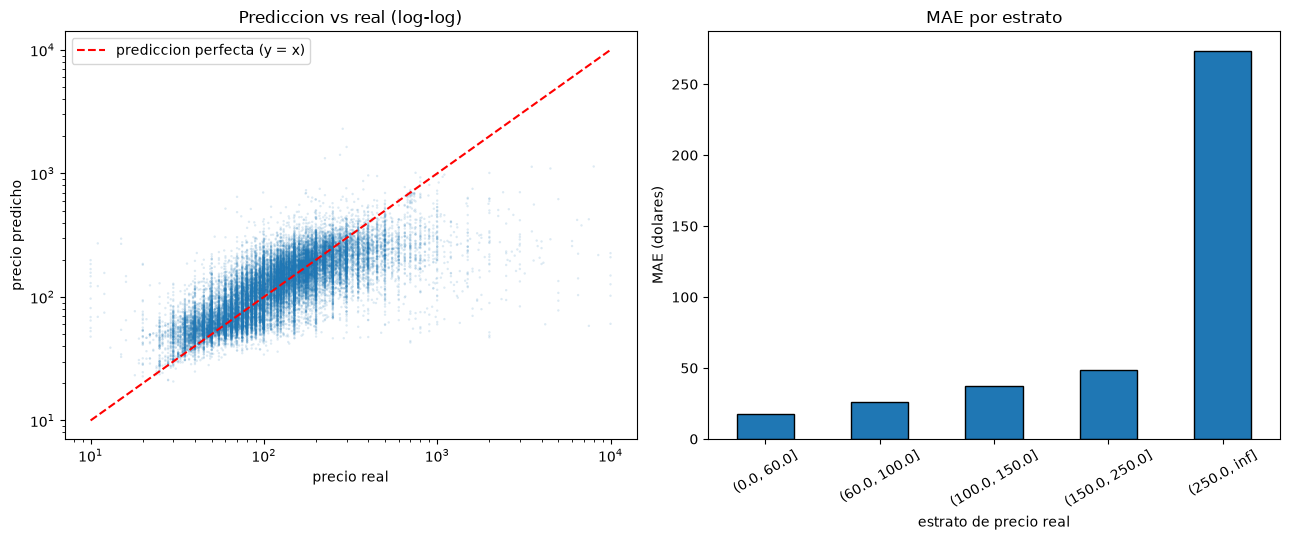

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

# 1) pred vs real en log-log
axs[0].scatter(e['y'], e['y_pred'], s=3, alpha=0.15, edgecolor='none')
lims = [e['y'].min(), e['y'].max()]
axs[0].plot(lims, lims, 'r--', lw=1.5, label='prediccion perfecta (y = x)')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel('precio real'); axs[0].set_ylabel('precio predicho')
axs[0].set_title('Prediccion vs real (log-log)')
axs[0].legend()

# 2) MAE por estrato
t = e.groupby('bin', observed=True).agg(**agg)
t['MAE'].plot(kind='bar', ax=axs[1], rot=30, edgecolor='black')
axs[1].set_ylabel('MAE (dolares)')
axs[1].set_xlabel('estrato de precio real')
axs[1].set_title('MAE por estrato')

plt.tight_layout()
plt.show()

### Conclusiones

* El modelo esta **bien calibrado hasta ~250 dolares**: agrupando por el valor
  predicho el sesgo es menor a 5 dolares. El MAE global de 60 no refleja eso.
* Se rompe en la cola: cuando predice mas de 500 el precio real promedio es
  bastante menor. No hay señal en las features (lat/long, room_type,
  availability) para distinguir un listing de 600 de uno de 3000 -- el precio
  de lujo depende del inmueble, no del barrio.
* El **MAE en dolares no es la metrica correcta** para este problema. Si el
  error que me importa es relativo, la metrica tiene que ser relativa: entreno
  con el target en log (`TransformedTargetRegressor`) y selecciono modelos por
  RMSLE / MAE en log-space, dejando el MAE en dolares por estrato como
  diagnostico.

**Decision pendiente sobre la cola (>500, ~2% de las filas):** recortarla del
train, tratarla como un problema aparte, o aceptarla y reportar el error por
estrato. Lo que no tiene sentido es seguir optimizando un RMSE dominado por
filas que el modelo no puede predecir.


# 7. Feature importance

Que features esta usando realmente el modelo. Hay dos formas de medirlo y no
dan lo mismo:

* **`feature_importances_`** del Random Forest: cuanto reduce la impureza cada
  feature al partir los nodos. Se calcula sobre el train y esta **sesgada**
  hacia features continuas y de alta cardinalidad -- un feature con muchos
  valores distintos tiene mas cortes posibles y acumula importancia aunque no
  sirva. Ademas opera sobre las features ya transformadas (los 10 clusters geo
  cuentan por separado).
* **`permutation_importance`**: rompe una columna barajandola y mide cuanto
  empeora la metrica en datos que el modelo no vio. Mide impacto real en
  performance, en unidades interpretables (dolares de MAE), y sobre las
  columnas **originales**.

La segunda es la que hay que mirar para tomar decisiones.


### 1. Importancia por impureza (built-in del RF)

In [73]:
model_imp = TransformedTargetRegressor(
    regressor=forest_reg, func=np.log1p, inverse_func=np.expm1
)
model_imp.fit(deptos, deptos_labels)

pipe  = model_imp.regressor_             # el Pipeline entrenado
rf    = pipe[-1]                         # el RandomForestRegressor
names = pipe[:-1].get_feature_names_out()  # nombres de las features transformadas

imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)
imp.round(4).to_frame('importancia')

,importancia
cat__room_type_Entire home/apt,0.3779
geo__Cluster 8 similarity,0.1016
geo__Cluster 0 similarity,0.0879
log1p__availability_365,0.0614
geo__Cluster 1 similarity,0.0446
reviews__reviews_per_month,0.0414
log1p__minimum_nights,0.0411
geo__Cluster 3 similarity,0.0390
geo__Cluster 9 similarity,0.0343
geo__Cluster 6 similarity,0.0311


### 2. Permutation importance (sobre validacion)

Uso un split interno del train: entreno en 80% y permuto sobre el 20% restante.
El test set sigue sin tocarse.

`n_repeats=5` baraja cada columna 5 veces para tener un desvio y saber si la
diferencia es señal o ruido.


In [77]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    deptos, deptos_labels, test_size=0.2, random_state=42
)

model_perm = TransformedTargetRegressor(
    regressor=forest_reg, func=np.log1p, inverse_func=np.expm1
)
model_perm.fit(X_tr, y_tr)

r = permutation_importance(
    model_perm, X_val, y_val, n_repeats=5, random_state=42,
    scoring='neg_mean_absolute_error',
)

perm = pd.DataFrame(
    {'importancia': r.importances_mean, 'std': r.importances_std},
    index=X_val.columns,
).sort_values('importancia', ascending=False)

# 'importancia' = cuantos dolares sube el MAE al romper esa columna
perm.round(3)

,importancia,std
room_type,27.053,0.313
longitude,14.035,0.527
latitude,10.185,0.391
minimum_nights,9.061,0.347
availability_365,8.122,0.377
calculated_host_listings_count,3.952,0.165
number_of_reviews,1.481,0.052
reviews_per_month,1.447,0.117
neighbourhood_group,0.034,0.005
neighbourhood,0.000,0.000


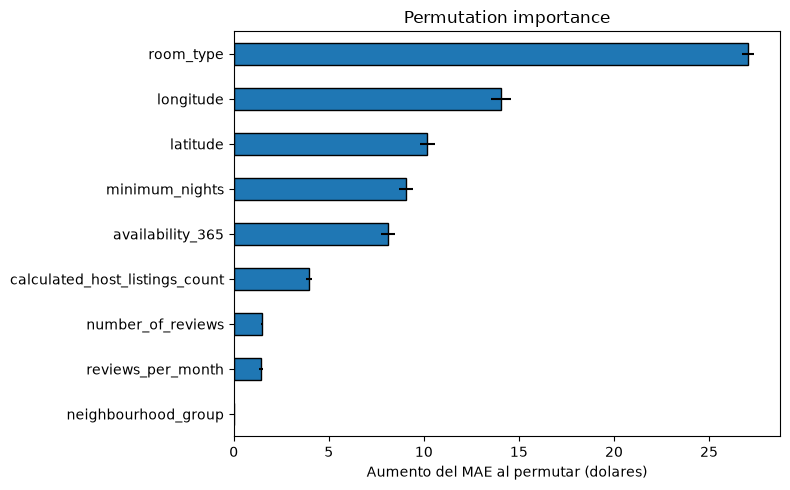

In [78]:
perm[perm['importancia'] > 0]['importancia'].sort_values().plot(
    kind='barh', figsize=(8, 5), xerr=perm[perm['importancia'] > 0]['std'],
    edgecolor='black'
)
plt.xlabel('Aumento del MAE al permutar (dolares)')
plt.title('Permutation importance')
plt.tight_layout()
plt.show()

### Conclusiones

* **`room_type` domina**: vale ~27 dolares de MAE, mas que lat/long juntos.
  Confirma lo que ya vimos en la exploracion. Y aun asi no alcanza: tiene 3
  niveles, y 893 de los 1044 listings de mas de 500 caen todos en
  `Entire home/apt`, la misma categoria cuya mediana es 160.

* **`neighbourhood_group` da ~0, pero NO significa que el barrio no importe.**
  Significa que `latitude`/`longitude` (via ClusterSimilarity) ya codifican esa
  informacion. La permutation importance **subestima features redundantes**:
  al romper una sola, el modelo compensa con la otra y la metrica no se mueve.
  Para medirlo bien habria que sacar el grupo completo de features
  correlacionadas a la vez. No borrar por este numero.

* **`never_reviewed` / `last_review` dan ~0**: el flag no aporta nada.
  `reviews_per_month` ya captura lo mismo (imputado en 0 cuando no hay reviews).
  Este si es candidato real a sacar del pipeline.

* La importancia por impureza infla los clusters geo (se reparten 0.43 entre
  los 10) porque son continuos y hay muchos. Es el sesgo tipico del metodo.


# 8. Baseline y busqueda de hiperparametros

Antes de tocar el test faltan dos cosas sin las cuales el numero final no se
puede interpretar:

1. **Una baseline tonta.** Un MAE de 57 no significa nada en abstracto. Si
   predecir siempre la mediana da 60, el modelo no aporta casi nada. La
   baseline es la unidad de medida.
2. **Tunear.** Todo lo anterior es un Random Forest con los defaults. Sin
   probar al menos una grilla de hiperparametros no se sabe si el techo de
   ~57 es del problema o de la configuracion.

Ambas cosas se hacen **sobre el train con validacion cruzada**. El test sigue
guardado.

### Baseline: DummyRegressor

In [ ]:
from sklearn.dummy import DummyRegressor

baselines = {
    'mediana': DummyRegressor(strategy='median'),
    'media':   DummyRegressor(strategy='mean'),
}

for nombre, m in baselines.items():
    mae = -cross_val_score(m, deptos, deptos_labels, cv=5,
                           scoring='neg_mean_absolute_error')
    print(f'{nombre:8s}  MAE CV: {mae.mean():6.2f}  +/- {mae.std():.2f}')

mae_rf = -cross_val_score(forest_reg_log, deptos, deptos_labels, cv=5,
                          scoring='neg_mean_absolute_error')
print(f'{"RF+log":8s}  MAE CV: {mae_rf.mean():6.2f}  +/- {mae_rf.std():.2f}')

La comparacion util no es la resta sino la reduccion relativa:

`mejora = (MAE_baseline - MAE_modelo) / MAE_baseline`

Si da menos de ~20% el modelo esta aprendiendo poco y conviene revisar las
features antes que los hiperparametros.

In [ ]:
mae_base = -cross_val_score(DummyRegressor(strategy='median'), deptos,
                            deptos_labels, cv=5,
                            scoring='neg_mean_absolute_error').mean()

print(f'Baseline (mediana): {mae_base:.2f}')
print(f'Random Forest+log : {mae_rf.mean():.2f}')
print(f'Mejora            : {(mae_base - mae_rf.mean()) / mae_base:.1%}')

### Busqueda de hiperparametros

`RandomizedSearchCV` en vez de `GridSearchCV`: con 6 hiperparametros una
grilla completa explota, y el random search encuentra casi lo mismo con una
fraccion de los fits.

Lo que se tunea incluye **el preprocesamiento**, no solo el modelo. `n_clusters`
y `gamma` del `ClusterSimilarity` los elegi a ojo (10 y 400); son
hiperparametros como cualquier otro y entran a la busqueda. La ruta del
parametro sigue la anidacion del objeto:

`regressor__` (sale del TransformedTargetRegressor)
`columntransformer__geo__` (el bloque geo del ColumnTransformer)
`n_clusters`

**Ojo con el tiempo**: `n_iter=20` con `cv=3` son 60 entrenamientos completos,
y cada uno reajusta el KMeans. Puede tardar 15-30 minutos.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    # preprocesamiento
    'regressor__columntransformer__geo__n_clusters': randint(5, 40),
    'regressor__columntransformer__geo__gamma':      [1., 10., 100., 400., 1000.],
    # modelo
    'regressor__randomforestregressor__n_estimators':     randint(100, 400),
    'regressor__randomforestregressor__max_features':     ['sqrt', 0.3, 0.5, 1.0],
    'regressor__randomforestregressor__min_samples_leaf': randint(1, 20),
    'regressor__randomforestregressor__max_depth':        [None, 10, 20, 30],
}

busqueda = RandomizedSearchCV(
    forest_reg_log,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda.fit(deptos, deptos_labels)

In [ ]:
res = pd.DataFrame(busqueda.cv_results_)
res['MAE'] = -res['mean_test_score']

cols = [c for c in res.columns if c.startswith('param_')] + ['MAE', 'std_test_score']
res[cols].sort_values('MAE').head(10).round(3)

In [ ]:
print('Mejores parametros:')
for k, v in busqueda.best_params_.items():
    print(f'  {k.split("__")[-1]:22s} = {v}')

print()
print(f'MAE tuneado  : {-busqueda.best_score_:.2f}')
print(f'MAE default  : {mae_rf.mean():.2f}')
print(f'Mejora       : {(mae_rf.mean() + busqueda.best_score_) / mae_rf.mean():.1%}')

### Conclusiones del tuning

*(completar con los numeros que salgan)*

Que mirar en la tabla de resultados:

* **Si la mejora es de pocos dolares**, el techo es del problema, no de la
  configuracion. Consistente con lo que vimos en la seccion 6: falta senal
  (`accommodates`, `bedrooms`) para separar la cola de precios altos.
* **Si `min_samples_leaf` optimo es alto** (>5), el modelo estaba
  sobreajustando con los defaults.
* **Si `n_clusters` optimo se va al borde de la grilla** (5 o 40), hay que
  ampliar el rango y volver a buscar.
* La desviacion entre folds (`std_test_score`) rondaba +/-2.7 en la seccion 7.
  Cualquier diferencia menor a eso entre dos configuraciones es ruido: no
  elijas la primera de la tabla si la segunda es mas simple y esta adentro
  del margen.

# 9. Evaluacion final en el test set

**Esto se hace una sola vez.** A partir del momento en que mire estos numeros,
cualquier cambio que haga al modelo mirandolos convierte al test en un segundo
set de validacion y el resultado deja de ser una estimacion honesta de la
performance en datos nuevos.

Decisiones que quedan congeladas antes de correr esta seccion:

* Modelo: Random Forest con el target en log (`TransformedTargetRegressor`),
  con los hiperparametros que gano la busqueda de la seccion 8.
* Preprocesamiento: el `preprocessing` tal como quedo definido.
* Alcance: sin recorte de precios -- evaluo sobre todo el rango, incluida la
  cola. Si mas adelante decido acotar el alcance a `price <= 500`, eso es un
  modelo distinto y necesita su propia evaluacion.
* El filtro `minimum_nights <= 365` fue una decision de **entrenamiento**. El
  test no se filtra: filtrar el test para que el numero salga mejor es
  hacer trampa.

### Entreno el modelo final sobre todo el train

In [ ]:
# RandomizedSearchCV ya reentreno el mejor modelo sobre todo el train
# (refit=True por defecto), asi que best_estimator_ viene listo para predecir.
modelo_final = busqueda.best_estimator_

# Si todavia no corriste la seccion 8, descomenta esto y usa los defaults:
# modelo_final = TransformedTargetRegressor(
#     regressor=make_pipeline(preprocessing,
#                             RandomForestRegressor(random_state=42, n_jobs=-1)),
#     func=np.log1p, inverse_func=np.expm1,
# ).fit(deptos, deptos_labels)

modelo_final

### Predigo sobre el test

`X_test` / `y_test` ya quedaron definidos en la seccion del pipeline. El test
solo se transforma con lo aprendido en train (eso pasa adentro del pipeline),
nunca se le hace `fit`.


In [80]:
X_test = test_set.drop(columns='price')
y_test = test_set['price'].copy()

y_test_pred = modelo_final.predict(X_test)

mae_test  = mean_absolute_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print(f'MAE  test: {mae_test:.2f}')
print(f'RMSE test: {rmse_test:.2f}')

MAE  test: 55.51
RMSE test: 177.18


### Intervalo de confianza

El MAE del test es una estimacion sobre una muestra: tiene incertidumbre.
El intervalo del 95% dice en que rango caeria si repitiera el experimento con
otra muestra del mismo tamaño.


In [81]:
from scipy import stats

ae_test = np.abs(y_test_pred - y_test)
n = len(ae_test)

ic = stats.t.interval(0.95, n - 1, loc=ae_test.mean(), scale=stats.sem(ae_test))
print(f'MAE test: {ae_test.mean():.2f}   IC 95%: [{ic[0]:.2f}, {ic[1]:.2f}]')

MAE test: 55.51   IC 95%: [52.17, 58.85]


### Comparacion contra la validacion cruzada

Si el MAE del test cae dentro del rango que daba la CV en train, no hubo
overfitting a las decisiones de modelado. Si es bastante peor, algo se filtro.


In [82]:
cv_mae = -cross_val_score(modelo_final, deptos, deptos_labels, cv=5,
                          scoring='neg_mean_absolute_error')

print(f'CV en train : {cv_mae.mean():.2f}  +/- {cv_mae.std():.2f}')
print(f'Test        : {mae_test:.2f}')

CV en train : 57.44  +/- 2.72
Test        : 55.51


### El resultado que importa: error por estrato

El MAE global sigue sin ser el numero a reportar. Repito sobre el test el
mismo desglose de la seccion 6.


In [84]:
e_test = pd.DataFrame({'y': y_test.values, 'y_pred': y_test_pred})
e_test['residuo'] = e_test['y_pred'] - e_test['y']
e_test['ae']      = e_test['residuo'].abs()
e_test['rel']     = e_test['ae'] / e_test['y']
e_test['bin']      = pd.cut(e_test['y'],    bins=bins)
e_test['bin_pred'] = pd.cut(e_test['y_pred'], bins=bins)

e_test.groupby('bin', observed=True).agg(**agg).round(2)

,n,precio_medio,pred_media,sesgo,MAE,MedAE,err_rel_mediano
bin,,,,,,,
"(0.0, 60.0]",2010,47.36,63.23,15.87,17.39,11.72,0.25
"(60.0, 100.0]",2773,83.05,96.96,13.91,26.35,17.10,0.20
"(100.0, 150.0]",2006,129.64,142.55,12.92,37.17,29.07,0.22
"(150.0, 250.0]",1946,198.65,188.44,-10.22,50.95,41.20,0.21
"(250.0, inf]",1042,489.01,250.23,-238.78,250.46,141.47,0.40


### Calibracion en el test

Agrupado por el valor **predicho**: cuando el modelo dice X, cuanto vale en
realidad. Este es el desglose que se reporta, porque es el unico que se puede
usar en produccion (ahi nunca conoces el precio real).

In [ ]:
e_test.groupby('bin_pred', observed=True).agg(**agg).round(2)

,n,precio_medio,pred_media,sesgo,MAE,MedAE,err_rel_mediano
bin_pred,,,,,,,
"(0.0, 60.0]",1472,57.22,51.18,-6.04,16.18,9.55,0.19
"(60.0, 100.0]",2689,85.35,76.84,-8.51,25.55,15.46,0.21
"(100.0, 150.0]",2221,138.88,123.96,-14.92,46.67,28.40,0.24
"(150.0, 250.0]",2620,217.60,189.79,-27.82,82.56,47.82,0.27
"(250.0, inf]",775,373.39,328.86,-44.53,168.04,96.00,0.33


### En que rango es confiable el modelo

La pregunta "cuanto se equivoca" no tiene una respuesta unica: depende del
rango. Lo que se reporta es un **intervalo empirico por estrato de prediccion**:
cuando el modelo dice X, entre que valores cae el precio real el 80% de las
veces.

El criterio de corte se define sobre el **train** (con las predicciones
out-of-fold de la seccion 6) y se **confirma** en el test. Definirlo mirando
el test seria elegir el umbral que hace quedar bien al modelo.

In [ ]:
def rango_confiable(df, sesgo_max=0.05, err_rel_max=0.35, n_min=300):
    """Intervalo empirico y veredicto de confiabilidad por estrato de prediccion.

    sesgo_max    : |sesgo| / mediana real tolerado (5%)
    err_rel_max  : error relativo mediano tolerado (35%)
    n_min        : filas minimas para que el estrato sea estadisticamente util
    """
    g = df.groupby('bin_pred', observed=True)

    q = g['y'].quantile([0.1, 0.5, 0.9]).unstack()
    q.columns = ['p10', 'p50', 'p90']

    q['n']       = g.size()
    q['ancho_%'] = ((q['p90'] - q['p10']) / q['p50'] * 100).round(0)
    q['sesgo']   = g['residuo'].mean()
    q['err_rel'] = g['rel'].median()

    q['confiable'] = ((q['sesgo'].abs() / q['p50'] < sesgo_max)
                      & (q['err_rel'] < err_rel_max)
                      & (q['n'] > n_min))
    return q.round(2)


print('--- TRAIN (out-of-fold) : aca se define el criterio ---')
display(rango_confiable(e))

print('--- TEST : aca se confirma ---')
display(rango_confiable(e_test))

Sin bins fijos, para encontrar el punto exacto donde se rompe. Los deciles de
la prediccion tienen todos el mismo `n`, asi que las diferencias entre filas
son senal y no tamano de muestra: el decil donde el sesgo se despega de cero
es el techo del modelo.

In [ ]:
e_test['decil'] = pd.qcut(e_test['y_pred'], 10)

(e_test.groupby('decil', observed=True)
       .agg(n=('y', 'size'), pred_media=('y_pred', 'mean'),
            y_medio=('y', 'mean'), sesgo=('residuo', 'mean'),
            err_rel=('rel', 'median'))
       .round(2))

### Contra la baseline, en el test

El ultimo control: la mejora sobre predecir siempre la mediana, medida en el
test y desglosada por estrato. Es perfectamente posible que el modelo mejore
mucho en el centro y **empeore** respecto de la baseline en la cola.

In [ ]:
mediana_train = deptos_labels.median()

comp = pd.DataFrame({
    'MAE_modelo':   e_test.groupby('bin', observed=True)['ae'].mean(),
    'MAE_baseline': (y_test - mediana_train).abs()
                        .groupby(pd.cut(y_test, bins=bins), observed=True).mean(),
    'n':            e_test.groupby('bin', observed=True).size(),
})
comp['mejora_%'] = ((comp['MAE_baseline'] - comp['MAE_modelo'])
                    / comp['MAE_baseline'] * 100).round(1)

print(f'Global -> modelo: {e_test["ae"].mean():.2f}   '
      f'baseline: {(y_test - mediana_train).abs().mean():.2f}')
comp.round(2)

### Guardo el modelo y su ficha

El pipeline completo: preprocesamiento y modelo en un solo objeto. Se puede
cargar y usar con `predict` sobre un DataFrame crudo, sin repetir ningun paso
de transformacion a mano.

Guardo tambien un `.json` al lado con la **ficha del modelo**: con que datos se
entreno, que metrica dio, y en que rango es confiable. Un `.pkl` suelto sin
esa informacion es inusable dentro de seis meses -- nadie va a saber si el
numero que devuelve se puede creer.

In [ ]:
import joblib, json
from pathlib import Path
from datetime import date

MODELS = Path('..') / 'models'
MODELS.mkdir(exist_ok=True)

joblib.dump(modelo_final, MODELS / 'airbnb_nyc_rf.pkl')

ficha = {
    'nombre':        'airbnb_nyc_rf',
    'fecha':         str(date.today()),
    'datos':         'AB_NYC_2019.csv',
    'target':        'price (USD por noche)',
    'n_train':       int(len(deptos)),
    'n_test':        int(len(y_test)),
    'modelo':        'RandomForest sobre log1p(price)',
    'hiperparams':   {k.split('__')[-1]: str(v)
                      for k, v in busqueda.best_params_.items()},
    'features':      list(deptos.columns),
    'metricas_test': {
        'MAE':   round(float(mae_test), 2),
        'MedAE': round(float(np.median(ae_test)), 2),
        'RMSE':  round(float(rmse_test), 2),
    },
    'baseline_mediana_MAE': round(float((y_test - mediana_train).abs().mean()), 2),
    'rango_confiable':      'completar con la tabla de rango_confiable(e_test)',
    'limitaciones': [
        'No hay features de tamano del inmueble (accommodates, bedrooms, beds).',
        'Se rompe en la cola de precios altos: subestima sistematicamente.',
        'Entrenado con precios de 2019, sin ajuste por inflacion ni estacionalidad.',
    ],
}

with open(MODELS / 'airbnb_nyc_rf.json', 'w', encoding='utf-8') as f:
    json.dump(ficha, f, indent=2, ensure_ascii=False)

print(json.dumps(ficha, indent=2, ensure_ascii=False))

# Para volver a usarlo:
# modelo = joblib.load(MODELS / 'airbnb_nyc_rf.pkl')
# modelo.predict(nuevos_datos)   # DataFrame con las mismas columnas crudas

## Conclusiones finales

*(los numeros del test van despues de correr la seccion 9)*

### Que se construyo

Un estimador de precio por noche para listings de Airbnb en NYC: Random Forest
sobre `log1p(price)`, con un preprocesamiento que combina imputacion,
transformacion logaritmica de las numericas sesgadas, one-hot de las
categoricas y similitud RBF a `n` centroides geograficos.

### Que se aprendio del error

* **El MAE global (~57) no es el resultado.** Es un promedio entre un modelo
  que erra 20-40 dolares en el grueso de los datos y una cola larga donde erra
  cientos. Reportarlo solo es esconder el problema.
* **El modelo esta bien calibrado hasta ~250 dolares** y se rompe arriba de
  eso: subestima sistematicamente los listings caros.
* **El error relativo es la metrica honesta** para este problema. Pasar el
  target a log mejoro el MAE de 67.8 a 57.4 justamente porque convierte la
  perdida en algo cercano a relativo.
* **La causa esta en los datos, no en el modelo.** No hay ninguna feature que
  distinga un listing de 600 de uno de 3000: `room_type` tiene 3 niveles y 893
  de los 1044 listings de mas de 500 son todos `Entire home/apt`. Faltan
  `accommodates`, `bedrooms`, `bathrooms`. Ningun hiperparametro arregla eso.

### Como se usa

El resultado que se entrega no es un numero sino un rango: *"cuando el modelo
predice entre A y B, el precio real cae en [p10, p90] el 80% de las veces"*.
Arriba del ultimo estrato marcado como `confiable`, la prediccion se reporta
como no confiable en vez de darse como valida.

### Que haria en el proximo ciclo, en este orden

1. **Features del texto de `name`** -- hoy esta en `drop_attribs`. Contiene
   "2BR", "Luxury", "Loft", "Penthouse": es el unico proxy de tamano y
   categoria que tiene el dataset. Es la mejora con mejor relacion
   esfuerzo/beneficio.
2. **Enriquecer con datos externos** o cambiar a un dataset que traiga
   `accommodates` / `bedrooms`. Es la solucion real al problema de la cola.
3. **Modelo de cuantiles** (`GradientBoostingRegressor(loss='quantile')` con
   alpha 0.1 / 0.5 / 0.9) para que cada prediccion venga con su intervalo, en
   vez de depender de una tabla estatica por estrato.
4. **Recortar el alcance** a `price <= 500` y declararlo explicitamente. Cubre
   el 98% de los listings, y un modelo honesto sobre el 98% vale mas que uno
   que finge cubrir el 100%.
5. Recien despues, probar `HistGradientBoostingRegressor`. El techo de ~57 es
   del problema, no del algoritmo: cambiar de modelo sin agregar senal no va a
   mover mucho la aguja.

### Que no se hace de aca en adelante

Volver a tunear mirando los numeros del test. Si quiero probar otra idea,
vuelvo a la validacion cruzada sobre el train, y el test queda guardado para
el final del proximo ciclo.